In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib as plt

In [2]:
#En este caso usaré la empresa Amazon, defino mi variable y el ticker de la empresa
ticker = "AMZN"

In [3]:
#Extraemos los datos a un año
datos = yf.download(ticker, period ="1y")

[*********************100%***********************]  1 of 1 completed


In [4]:
#Visualizamos los datos y extraemos lo que queremos
datos

Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2025-07-17,223.880005,224.500000,222.509995,223.320007,31855800
2025-07-18,226.130005,226.399994,222.979996,225.139999,37833800
2025-07-21,229.300003,229.690002,225.649994,225.839996,40297600
2025-07-22,227.470001,230.000000,226.350006,229.679993,37483700
2025-07-23,228.289993,228.789993,227.089996,228.470001,28294900
...,...,...,...,...,...
2026-07-10,245.339996,251.029999,244.410004,249.550003,31654000
2026-07-13,247.309998,249.649994,244.179993,244.679993,34636100


In [5]:
#Lo que queremos son los precios de cierre
precios_cierre = datos["Close"]

In [6]:
precios_cierre

Ticker,AMZN
Date,
2025-07-17,223.880005
2025-07-18,226.130005
2025-07-21,229.300003
2025-07-22,227.470001
2025-07-23,228.289993
...,...
2026-07-10,245.339996
2026-07-13,247.309998
2026-07-14,247.490005


In [9]:
#Hallamos el rendimiento_t
rendimiento_d = precios_cierre.pct_change().dropna()
rendimiento_d

Ticker,AMZN
Date,
2025-07-18,0.010050
2025-07-21,0.014018
2025-07-22,-0.007981
2025-07-23,0.003605
2025-07-24,0.017259
...,...
2026-07-10,-0.006881
2026-07-13,0.008030
2026-07-14,0.000728


In [11]:
#Rendimiento compuesto 
rday=rendimiento_d.shape[0]
rendimiento_compuesto = (rendimiento_d+1).prod()**(1/rday)-1
rendimiento_compuesto

Ticker
AMZN    0.00044
dtype: float64

In [12]:
#Rendimiento anualizado
rm_a = (rendimiento_compuesto+1)**252-1
rm_a

Ticker
AMZN    0.11716
dtype: float64

<Axes: xlabel='Date'>

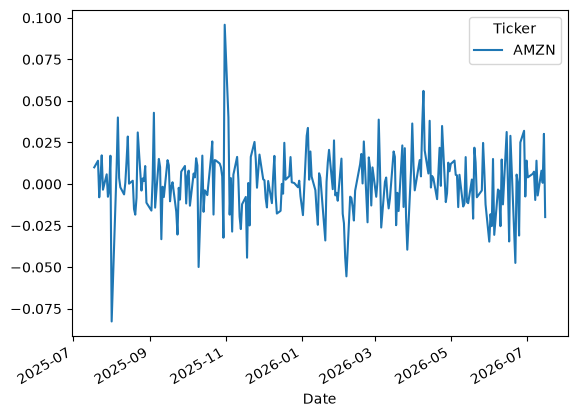

In [13]:
#Gráfica de rendimiento_d
rendimiento_d.plot()